In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import pandas as pd


In [ ]:
Data = pd.read_excel(r'/content/gdrive/My Drive/Data/ApexPlanet_DataAnalytics_Dataset.xlsx')

In [ ]:
display(pd.DataFrame(Data))

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90
...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD100997,2025-11-07,CUST6410,Customer_301,61.0,Male,Gaya,Laptop,Electronics,9,35405.54,318649.86
996,ORD100998,2025-09-03,CUST7618,Customer_154,25.0,Male,Gaya,Shoes,Fashion,5,18454.65,92273.25
997,ORD100999,2025-09-30,CUST9544,Customer_140,62.0,Female,Hyderabad,Laptop,Electronics,9,12971.59,116744.31
998,ORD101000,2025-02-21,CUST9501,Customer_241,NaN,Male,Delhi,Mobile,Electronics,9,2879.01,25911.09


In [ ]:
# Overview of dataset structure
Data.info()

# Summary statistics for numeric and categorical columns
Data.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
count,1000,1000,1000,1000,980.000000,1000,987,1000,1000,1000.000000,1000.000000,1000.000000
unique,992,342,947,425,NaN,2,8,6,5,NaN,NaN,NaN
top,ORD100050,2025-04-16,CUST2515,Customer_359,NaN,Male,Patna,Mobile,Electronics,NaN,NaN,NaN
freq,9,10,3,8,NaN,511,135,184,354,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,41.360204,NaN,NaN,NaN,NaN,5.435000,25486.783410,139399.439650
std,NaN,NaN,NaN,NaN,13.822597,NaN,NaN,NaN,NaN,2.838632,14179.402361,114100.051546
min,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,1.000000,145.780000,437.340000
25%,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,3.000000,13895.722500,47066.632500
50%,NaN,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,5.000000,25398.740000,108594.025000
75%,NaN,NaN,NaN,NaN,54.000000,NaN,NaN,NaN,NaN,8.000000,37512.382500,203722.882500


In [ ]:
# Count missing values per column
missing = Data.isnull().sum()
print("Missing values:\n", missing)


Missing values:
 Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64


In [ ]:
# Count duplicate rows
duplicates = Data.duplicated().sum()
print("Duplicate rows:", duplicates)

# Remove duplicates if needed
Data = Data.drop_duplicates()


Duplicate rows: 0


In [ ]:
# Check column data types
print(Data.dtypes)

# Convert date column to datetime
Data['Order_Date'] = pd.to_datetime(Data['Order_Date'], errors='coerce')

# Verify conversion
print(Data['Order_Date'].head())


Order_ID          object
Order_Date        object
Customer_ID       object
Customer_Name     object
Age              float64
Gender            object
City              object
Product           object
Category          object
Quantity           int64
Unit_Price       float64
Total_Sales      float64
dtype: object
0   2025-02-25
1   2025-10-14
2   2025-05-13
3   2025-12-02
4   2025-11-20
Name: Order_Date, dtype: datetime64[ns]


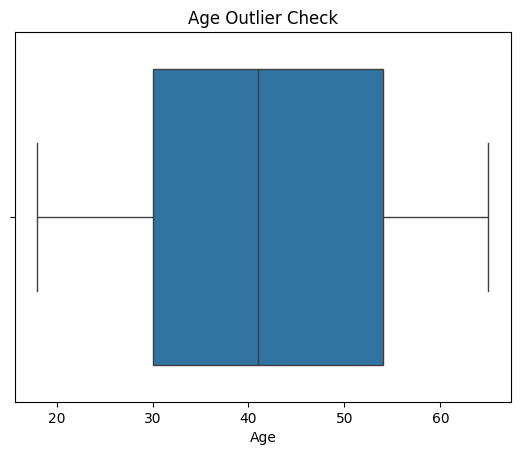

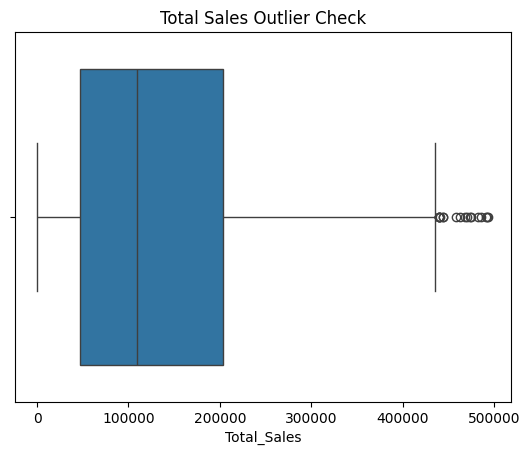

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Age column
sns.boxplot(x=Data['Age'])
plt.title('Age Outlier Check')
plt.show()

# Example: Total_Sales column
sns.boxplot(x=Data['Total_Sales'])
plt.title('Total Sales Outlier Check')
plt.show()


In [ ]:
# Fill missing numeric values with median
Data['Age'] = Data['Age'].fillna(Data['Age'].median())

# Fill missing categorical values with 'Unknown'
for col in ['Gender','City','Product','Category']:
    Data[col] = Data[col].fillna('Unknown')

# Drop duplicate rows
Data = Data.drop_duplicates()


In [ ]:
# Convert Order_Date to datetime
Data['Order_Date'] = pd.to_datetime(Data['Order_Date'], errors='coerce')

# Extract useful features
Data['Order_Year'] = Data['Order_Date'].dt.year
Data['Order_Month'] = Data['Order_Date'].dt.month
Data['Order_Day'] = Data['Order_Date'].dt.day


In [ ]:
# Standardize text formatting
Data['City'] = Data['City'].str.strip().str.title()
Data['Product'] = Data['Product'].str.strip().str.title()
Data['Category'] = Data['Category'].str.strip().str.title()
Data['Customer_Name'] = Data['Customer_Name'].str.strip().str.title()


In [ ]:
# Recalculate Total_Sales to validate
Data['Total_Sales_Calc'] = Data['Quantity'] * Data['Unit_Price']

# Flag mismatches
Data['Sales_Match'] = Data['Total_Sales'].round(2) == Data['Total_Sales_Calc'].round(2)

# Create Age Groups
Data['Age_Group'] = pd.cut(Data['Age'],
                           bins=[0,18,30,45,60,100],
                           labels=['Teen','Young Adult','Adult','Middle Age','Senior'])

# Example: Customer Age from Date of Birth (if DOB column exists)
if 'DOB' in Data.columns:
    Data['DOB'] = pd.to_datetime(Data['DOB'], errors='coerce')
    Data['Customer_Age'] = (pd.Timestamp.today().year - Data['DOB'].dt.year)


In [ ]:
# Save cleaned dataset
Data.to_csv("Cleaned_Sales_Dataset.csv", index=False)

print(" Step 3 complete: Cleaned dataset saved as Cleaned_Sales_Dataset.csv")


 Step 3 complete: Cleaned dataset saved as Cleaned_Sales_Dataset.csv


In [ ]:
from google.colab import files
files.download('Cleaned_Sales_Dataset.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>